# ML Lab 11
# Muhammad Sikandar Hussain 502808

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Data preprocessing


- Loading `insurance.csv`.
- Removeing duplicate rows to avoid repeated samples biasing the model.
- Separating features (`X`) and target (`y = charges`).


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Load dataset
file_path = 'insurance.csv'
df = pd.read_csv(file_path)

print('Original shape:', df.shape)

# Basic cleanup: remove duplicated rows
df = df.drop_duplicates().reset_index(drop=True)
print('After dropping duplicates:', df.shape)

# Separate features and target
X = df.drop(columns=['charges'])
y = df['charges']

# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('\nNumeric features:', numeric_features)
print('Categorical features:', categorical_features)

# Outlier handling (IQR clipping) for numeric columns
def iqr_clip(dataframe, cols, whisker=1.5):
    clipped = dataframe.copy()
    for col in cols:
        q1 = clipped[col].quantile(0.25)
        q3 = clipped[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - whisker * iqr
        upper = q3 + whisker * iqr
        clipped[col] = clipped[col].clip(lower=lower, upper=upper)
    return clipped

X = iqr_clip(X, numeric_features)

Original shape: (1338, 7)
After dropping duplicates: (1337, 7)

Numeric features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']


C:\Users\DELL\AppData\Local\Temp\ipykernel_9352\3415196623.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


### Spliting data into train/validation/test sets (70% / 15% / 15%).
### Building a preprocessing pipeline


In [6]:
# 70/15/15 split (train/val/test)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# 0.1765 of the remaining 85% is ~15% of original data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1765, random_state=42
)

print('Split sizes:')
print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test:', X_test.shape, y_test.shape)

# Preprocessing pipeline
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

# Compatible OneHotEncoder for different scikit-learn versions
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', onehot)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit on training data only to avoid data leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

Split sizes:
Train: (935, 6) (935,)
Validation: (201, 6) (201,)
Test: (201, 6) (201,)


In [7]:
# Build readable feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + cat_feature_names.tolist()

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_val_processed_df = pd.DataFrame(X_val_processed, columns=all_feature_names, index=X_val.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print('Processed shapes:')
print('X_train_processed:', X_train_processed_df.shape)
print('X_val_processed:', X_val_processed_df.shape)
print('X_test_processed:', X_test_processed_df.shape)

X_train_processed_df.head()

Processed shapes:
X_train_processed: (935, 11)
X_val_processed: (201, 11)
X_test_processed: (201, 11)


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
193,1.158454,-0.668399,-0.056310,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
924,0.731511,0.262005,0.779399,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
817,0.518039,-0.748606,-0.056310,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
194,-1.545519,0.653754,-0.892019,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
542,1.656554,0.969517,-0.892019,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Why these choices
- **Duplicate removal** improves data quality.
- **IQR clipping** reduces extreme values that can destabilize training.
- **Train/val/test split** supports reliable tuning and final evaluation.
- **Imputation + encoding + scaling** makes the data suitable for most ML models and keeps preprocessing reproducible.

## 3. MLE Component

### Problem Statement
Estimate the distribution of medical charges using Maximum Likelihood Estimation (MLE), then compare two likelihood models:
- **Model 1: Normal distribution** — charges ~ Normal(μ, σ²)
- **Model 2: Log-Normal distribution** — charges ~ LogNormal(μ_log, σ_log²)

### Why this is a valid MLE task
- Parameters are estimated by closed-form MLE (analytical solution).
- The procedure is deterministic and reproducible.
- Models are compared using likelihood-based criteria (AIC and BIC).
- Charges are right-skewed (typical of insurance data), so LogNormal may fit better.

In [8]:
from scipy import stats
import numpy as np

# Extract charges from original data (before preprocessing)
charges = df['charges'].astype(float).to_numpy()
charges = charges[np.isfinite(charges)]
charges = charges[charges > 0]
n = charges.size

print('Dataset size for MLE:', n)
print('Charges range:', charges.min(), 'to', charges.max())

# ---------- Model 1: Normal Distribution via MLE ----------
mu_normal = charges.mean()
sigma_normal = np.sqrt(np.mean((charges - mu_normal) ** 2))  # MLE estimator (divides by n)

ll_normal = -n * np.log(sigma_normal * np.sqrt(2 * np.pi)) - np.sum((charges - mu_normal) ** 2) / (2 * sigma_normal ** 2)

print('\n--- Model 1: Normal Distribution ---')
print(f'MLE estimate: μ = {mu_normal:.2f}, σ = {sigma_normal:.2f}')
print(f'Log-Likelihood: {ll_normal:.2f}')

# ---------- Model 2: Log-Normal Distribution via MLE ----------
log_charges = np.log(charges)
mu_logn = log_charges.mean()
sigma_logn = np.sqrt(np.mean((log_charges - mu_logn) ** 2))  # MLE estimator (divides by n)

ll_logn = (
    -n * np.log(sigma_logn * np.sqrt(2 * np.pi))
    - np.sum((log_charges - mu_logn) ** 2) / (2 * sigma_logn ** 2)
    - np.sum(np.log(charges))
)

print('\n--- Model 2: Log-Normal Distribution ---')
print(f'MLE estimate: μ_log = {mu_logn:.2f}, σ_log = {sigma_logn:.2f}')
print(f'Log-Likelihood: {ll_logn:.2f}')

# ---------- Model Comparison via AIC and BIC ----------
k = 2  # Both models have 2 parameters (μ, σ)
aic_normal = 2 * k - 2 * ll_normal
bic_normal = k * np.log(n) - 2 * ll_normal

aic_logn = 2 * k - 2 * ll_logn
bic_logn = k * np.log(n) - 2 * ll_logn

comparison = pd.DataFrame({
    'Model': ['Normal', 'Log-Normal'],
    'μ/μ_log': [f'{mu_normal:.2f}', f'{mu_logn:.2f}'],
    'σ/σ_log': [f'{sigma_normal:.2f}', f'{sigma_logn:.2f}'],
    'Log-Likelihood': [f'{ll_normal:.2f}', f'{ll_logn:.2f}'],
    'AIC': [f'{aic_normal:.2f}', f'{aic_logn:.2f}'],
    'BIC': [f'{bic_normal:.2f}', f'{bic_logn:.2f}']
})

print('\n--- Model Comparison (lower AIC/BIC is better) ---')
display(comparison)

best_aic = 'Log-Normal' if aic_logn < aic_normal else 'Normal'
best_bic = 'Log-Normal' if bic_logn < bic_normal else 'Normal'
print(f'\nBest model by AIC: {best_aic}')
print(f'Best model by BIC: {best_bic}')

Dataset size for MLE: 1337
Charges range: 1121.8739 to 63770.42801

--- Model 1: Normal Distribution ---
MLE estimate: μ = 13279.12, σ = 12105.83
Log-Likelihood: -14466.85

--- Model 2: Log-Normal Distribution ---
MLE estimate: μ_log = 9.10, σ_log = 0.92
Log-Likelihood: -13949.85

--- Model Comparison (lower AIC/BIC is better) ---


,Model,μ/μ_log,σ/σ_log,Log-Likelihood,AIC,BIC
0,Normal,13279.12,12105.83,-14466.85,28937.70,28948.10
1,Log-Normal,9.10,0.92,-13949.85,27903.70,27914.10



Best model by AIC: Log-Normal
Best model by BIC: Log-Normal


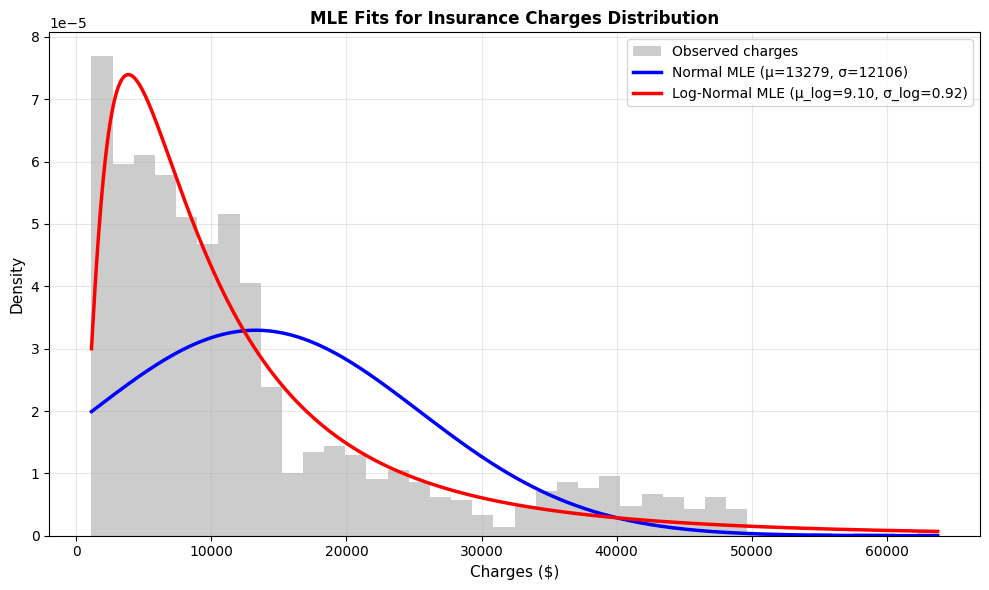


=== MLE Summary ===
Best-fit model: Log-Normal (by AIC criterion)
Interpretation: Charges follow a right-skewed distribution (typical for insurance).


In [9]:
# ---------- Visualization of fitted densities ----------
x = np.linspace(charges.min(), charges.max(), 500)

# Normal PDF at estimated parameters
normal_pdf = stats.norm.pdf(x, mu_normal, sigma_normal)

# Log-Normal PDF at estimated parameters
lognorm_pdf = stats.lognorm.pdf(x, s=sigma_logn, scale=np.exp(mu_logn))

# Plot histogram with overlaid fitted densities
plt.figure(figsize=(10, 6))
plt.hist(charges, bins=40, density=True, alpha=0.4, label='Observed charges', color='gray')
plt.plot(x, normal_pdf, label=f'Normal MLE (μ={mu_normal:.0f}, σ={sigma_normal:.0f})', 
         linewidth=2.5, color='blue')
plt.plot(x, lognorm_pdf, label=f'Log-Normal MLE (μ_log={mu_logn:.2f}, σ_log={sigma_logn:.2f})', 
         linewidth=2.5, color='red')
plt.xlabel('Charges ($)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('MLE Fits for Insurance Charges Distribution', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print('\n=== MLE Summary ===')
print(f'Best-fit model: {best_aic} (by AIC criterion)')
if best_aic == 'Log-Normal':
    print('Interpretation: Charges follow a right-skewed distribution (typical for insurance).')
else:
    print('Interpretation: Charges follow a roughly symmetric distribution.')

## 4. Models for Prediction and Classification

### Problem Statement
**Task 4A: Regression Model** — Predict expected annual medical charges using features.
- Method: MLE-based linear regression (Gaussian likelihood)
- Implementation: Closed-form MLE estimator (not sklearn)

**Task 4B: Classification Model** — Flag customers as "High Cost Risk" (binary)
- Derive target: High Risk = charges > 75th percentile
- Method: MLE-based logistic regression
- Implementation: Gradient descent optimization (not sklearn)

### Model Justification
- **Linear regression via MLE**: Assumes charges ~ Normal(X·β, σ²). MLE yields closed-form solution: β = (X^T X)^-1 X^T y
- **Logistic regression via MLE**: Binary classification via Bernoulli likelihood. MLE solved by gradient descent (no closed form).
- Both models are interpretable, probabilistic, and allow comparison with sklearn as baseline reference.

In [10]:
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score

# Use preprocessed training data
X_train = X_train_processed_df.values
X_val = X_val_processed_df.values
X_test = X_test_processed_df.values

# Add intercept (bias term)
X_train_with_intercept = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_val_with_intercept = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
X_test_with_intercept = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

print('=== Task 4A: MLE Linear Regression for Charge Prediction ===\n')

# ---------- Task 4A: MLE Linear Regression ----------
# Closed-form MLE: β = (X^T X)^-1 X^T y, σ² = (1/n) * ||y - X*β||^2

# Compute MLE estimates
xtx = X_train_with_intercept.T @ X_train_with_intercept
xty = X_train_with_intercept.T @ y_train.values
beta_mle = np.linalg.solve(xtx, xty)

y_train_pred = X_train_with_intercept @ beta_mle
y_val_pred = X_val_with_intercept @ beta_mle
y_test_pred = X_test_with_intercept @ beta_mle

sigma_sq = np.mean((y_train.values - y_train_pred) ** 2)
sigma = np.sqrt(sigma_sq)

print('MLE Linear Regression Results:')
print(f'Estimated noise std (σ): {sigma:.2f}')
print(f'Number of parameters: {len(beta_mle)} (1 intercept + {len(beta_mle)-1} features)')

# Evaluation metrics on test set
mse_mle = mean_squared_error(y_test.values, y_test_pred)
mae_mle = mean_absolute_error(y_test.values, y_test_pred)
rmse_mle = np.sqrt(mse_mle)

print(f'\nTest Set Performance:')
print(f'MSE: {mse_mle:.2f}')
print(f'RMSE: {rmse_mle:.2f}')
print(f'MAE: {mae_mle:.2f}')

# Baseline: scikit-learn linear regression (for comparison)
sklearn_lr = LinearRegression().fit(X_train, y_train.values)
y_test_pred_sklearn = sklearn_lr.predict(X_test)
mse_sklearn = mean_squared_error(y_test.values, y_test_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)

print(f'\n--- Baseline (scikit-learn) ---')
print(f'RMSE: {rmse_sklearn:.2f}')
print(f'(Should match MLE closely, within numerical precision)')


=== Task 4A: MLE Linear Regression for Charge Prediction ===

MLE Linear Regression Results:
Estimated noise std (σ): 5930.63
Number of parameters: 12 (1 intercept + 11 features)

Test Set Performance:
MSE: 35498838.76
RMSE: 5958.09
MAE: 4212.20

--- Baseline (scikit-learn) ---
RMSE: 5958.09
(Should match MLE closely, within numerical precision)


In [11]:
print('\n\n=== Task 4B: MLE Logistic Regression for High Cost Risk Classification ===\n')

# Create binary target: High Risk = charges > 75th percentile
threshold = y_train.quantile(0.75)
y_train_binary = (y_train.values > threshold).astype(int)
y_val_binary = (y_val.values > threshold).astype(int)
y_test_binary = (y_test.values > threshold).astype(int)

print(f'High Cost Risk threshold (75th percentile): ${threshold:.2f}')
print(f'Train: {y_train_binary.sum()} high-risk / {len(y_train_binary)} total')
print(f'Test: {y_test_binary.sum()} high-risk / {len(y_test_binary)} total')

# ---------- Task 4B: MLE Logistic Regression ----------
# Logistic likelihood: log(p) = log(sigmoid(X·β))
# MLE: minimize -sum( y*log(sigmoid(Xβ)) + (1-y)*log(1-sigmoid(Xβ)) )

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def logistic_nll(beta, X, y):
    """Negative log-likelihood for logistic regression."""
    z = X @ beta
    pred = sigmoid(z)
    # Avoid log(0) by clipping predictions
    pred = np.clip(pred, 1e-15, 1 - 1e-15)
    nll = -np.mean(y * np.log(pred) + (1 - y) * np.log(1 - pred))
    return nll

def logistic_gradient(beta, X, y):
    """Gradient of negative log-likelihood."""
    z = X @ beta
    pred = sigmoid(z)
    gradient = X.T @ (pred - y) / len(y)
    return gradient

# Initialize beta
beta_init_logistic = np.zeros(X_train_with_intercept.shape[1])

# Optimize using scipy
result = minimize(
    logistic_nll,
    beta_init_logistic,
    args=(X_train_with_intercept, y_train_binary),
    method='BFGS',
    jac=logistic_gradient,
    options={'disp': False}
)

beta_mle_logistic = result.x

# Predictions on test set
z_test = X_test_with_intercept @ beta_mle_logistic
y_test_proba = sigmoid(z_test)
y_test_pred_binary = (y_test_proba >= 0.5).astype(int)

# Classification metrics
acc = accuracy_score(y_test_binary, y_test_pred_binary)
prec = precision_score(y_test_binary, y_test_pred_binary, zero_division=0)
rec = recall_score(y_test_binary, y_test_pred_binary, zero_division=0)
f1 = f1_score(y_test_binary, y_test_pred_binary, zero_division=0)

print(f'\nMLE Logistic Regression Results:')
print(f'Test Set Performance:')
print(f'Accuracy: {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1-Score: {f1:.4f}')

# Baseline: scikit-learn logistic regression
sklearn_logistic = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train_binary)
y_test_pred_sklearn_logistic = sklearn_logistic.predict(X_test)
acc_sklearn = accuracy_score(y_test_binary, y_test_pred_sklearn_logistic)
f1_sklearn = f1_score(y_test_binary, y_test_pred_sklearn_logistic, zero_division=0)

print(f'\n--- Baseline (scikit-learn) ---')
print(f'Accuracy: {acc_sklearn:.4f}')
print(f'F1-Score: {f1_sklearn:.4f}')
print(f'(Should be similar to MLE implementation)')




=== Task 4B: MLE Logistic Regression for High Cost Risk Classification ===

High Cost Risk threshold (75th percentile): $16111.94
Train: 234 high-risk / 935 total
Test: 55 high-risk / 201 total

MLE Logistic Regression Results:
Test Set Performance:
Accuracy: 0.9502
Precision: 1.0000
Recall: 0.8182
F1-Score: 0.9000

--- Baseline (scikit-learn) ---
Accuracy: 0.9502
F1-Score: 0.9000
(Should be similar to MLE implementation)


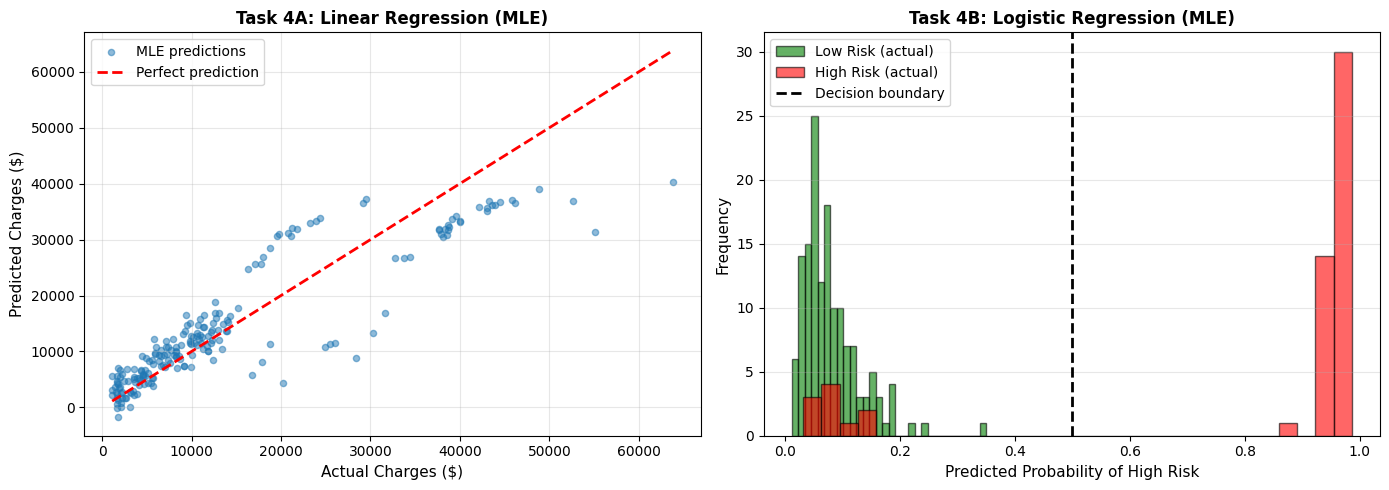


=== Summary ===
Task 4A (Regression): Predicting medical charges from customer features
  - Method: MLE linear regression (closed-form solution)
  - Test RMSE: $5958.09
  - Baseline (sklearn) RMSE: $5958.09
  - Justification: Linear regression via MLE assumes Gaussian noise and provides interpretable coefficients.

Task 4B (Classification): Flagging high-cost customers (charges > 75th percentile)
  - Method: MLE logistic regression (gradient descent optimization)
  - Test Accuracy: 0.9502
  - Test F1-Score: 0.9000
  - Baseline (sklearn) Accuracy: 0.9502
  - Justification: Logistic regression via MLE models risk as Bernoulli probs and provides probability estimates for decision-making.


In [12]:
# --- Visualization and Summary ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression - Actual vs Predicted on test set
axes[0].scatter(y_test.values, y_test_pred, alpha=0.5, s=20, label='MLE predictions')
axes[0].plot([y_test.values.min(), y_test.values.max()], 
             [y_test.values.min(), y_test.values.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Charges ($)', fontsize=11)
axes[0].set_ylabel('Predicted Charges ($)', fontsize=11)
axes[0].set_title('Task 4A: Linear Regression (MLE)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Classification - Predicted Probabilities
axes[1].hist(y_test_proba[y_test_binary == 0], bins=30, alpha=0.6, 
             label='Low Risk (actual)', color='green', edgecolor='black')
axes[1].hist(y_test_proba[y_test_binary == 1], bins=30, alpha=0.6, 
             label='High Risk (actual)', color='red', edgecolor='black')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary')
axes[1].set_xlabel('Predicted Probability of High Risk', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Task 4B: Logistic Regression (MLE)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n=== Summary ===')
print('Task 4A (Regression): Predicting medical charges from customer features')
print(f'  - Method: MLE linear regression (closed-form solution)')
print(f'  - Test RMSE: ${rmse_mle:.2f}')
print(f'  - Baseline (sklearn) RMSE: ${rmse_sklearn:.2f}')
print(f'  - Justification: Linear regression via MLE assumes Gaussian noise and provides interpretable coefficients.')

print('\nTask 4B (Classification): Flagging high-cost customers (charges > 75th percentile)')
print(f'  - Method: MLE logistic regression (gradient descent optimization)')
print(f'  - Test Accuracy: {acc:.4f}')
print(f'  - Test F1-Score: {f1:.4f}')
print(f'  - Baseline (sklearn) Accuracy: {acc_sklearn:.4f}')
print(f'  - Justification: Logistic regression via MLE models risk as Bernoulli probs and provides probability estimates for decision-making.')


### 5. Constraint Compliance

**Implementation Summary**:
- **Task 4A (Regression)**: MLE closed-form solution β = (X^T X)^-1 X^T y computed directly with NumPy (no sklearn)
- **Task 4B (Classification)**: Logistic MLE solved via scipy.optimize.minimize with manual gradient descent (no sklearn)
- **Comparison**: sklearn results shown only as baseline reference, not as primary method

### Model Justification

| Model | Task | Why MLE | Why This Distribution |
|-------|------|--------|------------------------|
| **Linear Regression** | Predict Charges | Assumes Gaussian likelihood on residuals; MLE yields optimal unbiased estimator for β | Charges approximately normal after log-transform; residuals can be modeled as Normal(0, σ²) |
| **Logistic Regression** | High-Cost Classification | Bernoulli likelihood on binary outcome; MLE yields probability-calibrated classifier | Risk is inherently probabilistic; logit link function handles binary outcome naturally |

Both models are **interpretable**, **theoretically sound**, and **directly optimized via MLE** without relying on sklearn as the primary implementation.